These machine learnig exercise attempts to solve Rossman 6 weeks sales Foecast on Kaggle.
There are two models in the code, since the test csv does not have sales to caclcuate R2 and rmse score:
1. Split train data into train of 70% and test of 30% for self validation
2. Used the test data from Rossman code challenge

In [1]:
pip install -- pandas numpy scikit-learn  matplotlib seaborn joblib factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=e11541ab77985d634ccd7d98c4ebd975ac699aaf0fef83e566e49e8da52d19db
  Stored in directory: /root/.cache/pip/wheels/87/6e/8f/914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor_analyzer


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

file_path = '/content/drive/My Drive/Data Science Projects/Sales_Forecast/Ml_train_sales_forecast_data (1).csv'
train_df = pd.read_csv(file_path)

print(train_df.head())


/tmp/ipykernel_2020/3247116528.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(file_path)


   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

In [4]:
import pandas as pd

file_path = '/content/drive/My Drive/Data Science Projects/Sales_Forecast/Ml_test_sales_forecast_data (1).csv'
test_df = pd.read_csv(file_path)

print(test_df.head())


   Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday  \
0   1      1          4  2015-09-17   1.0      1            0              0   
1   2      3          4  2015-09-17   1.0      1            0              0   
2   3      7          4  2015-09-17   1.0      1            0              0   
3   4      8          4  2015-09-17   1.0      1            0              0   
4   5      9          4  2015-09-17   1.0      1            0              0   

  StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0         c          a               1270.0                        9.0   
1         a          a              14130.0                       12.0   
2         a          c              24000.0                        4.0   
3         a          a               7520.0                       10.0   
4         a          c               2030.0                        8.0   

   CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
0

/tmp/ipykernel_2020/3319640761.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(file_path)


Feature engineering, selction and transformation for main train data split into train and test

Correcting State Holiday Data type in train_data

In [5]:
train_df['StateHoliday'] = train_df['StateHoliday'].astype(str)

Extracting features for effective modeling

In [6]:
train_df['Promo_weekend'] = (train_df['DayOfWeek'] >= 5) & (train_df['Promo'] == 1)


In [7]:
train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df['Year'] = train_df['Date'].dt.year.astype(int)
train_df['Month'] = train_df['Date'].dt.month.astype(int)
train_df['Week']= train_df['Date'].dt.isocalendar().week.astype(int)

In [24]:

train_df['7days_Sales_rolling_mean'] = train_df['Sales'].rolling(window=7).mean()
train_df['14days_Sales_rolling_mean'] = train_df['Sales'].rolling(window=14).mean()
train_df['28days_Sales_rolling_mean'] = train_df['Sales'].rolling(window=28).mean()
train_df['3_days_Sales_rolling_mean'] = train_df['Sales'].rolling(window=3).mean()
train_df['365days_Sales_rolling_mean'] = train_df['Sales'].rolling(window=365).mean()

In [25]:
df_numeric = df_numeric= train_df[['DayOfWeek', 'Promo','Promo_weekend','Open', '3_days_Sales_rolling_mean','7days_Sales_rolling_mean','14days_Sales_rolling_mean','28days_Sales_rolling_mean','365days_Sales_rolling_mean','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear' ]]


In [26]:
# Iterate through the numerical columns defined in df_numeric and fill NaNs in train_df
for col in df_numeric.columns:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna(train_df[col].median())

numerical Feature Selection using Factor Analyser

In [27]:
#Feature selection for numerical_features
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler

# Scale the numerical data
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_numeric)

# Initialize and fit FactorAnalyzer with 5 factors
fa = FactorAnalyzer(n_factors=5, rotation='varimax', method='ml') # 'varimax' for orthogonal rotation
fa.fit(numeric_scaled)

# Get loadings
loadings = pd.DataFrame(fa.loadings_, index=df_numeric.columns, columns=[f'Factor{i+1}' for i in range(5)])
print("Factor loadings:\n", loadings.round(3))

# Communalities (how much variance each variable explains)
communalities = pd.Series(fa.get_communalities(), index=df_numeric.columns)
print("\nCommunalities:\n", communalities.round(3))

# Select variables with strong loadings (absolute value > 0.5 on any factor)
selected_vars = loadings[loadings.abs().max(axis=1) > 0.5].index.tolist()
print("\nVariables chosen by factor analysis (|loading| > 0.5):\n")
print(selected_vars)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor loadings:
                             Factor1  Factor2  Factor3  Factor4  Factor5
DayOfWeek                    -0.650    0.200   -0.197    0.183   -0.043
Promo                         0.550    0.302    0.499    0.025   -0.057
Promo_weekend                 0.062    0.993    0.065   -0.010    0.005
Open                          0.890    0.045   -0.396   -0.176    0.110
3_days_Sales_rolling_mean     0.900    0.070    0.049    0.191    0.175
7days_Sales_rolling_mean      0.957    0.075    0.059    0.212    0.140
14days_Sales_rolling_mean     0.976    0.078    0.046    0.158   -0.016
28days_Sales_rolling_mean     0.982    0.078    0.049    0.115   -0.096
365days_Sales_rolling_mean    0.878    0.061    0.197    0.004   -0.104
CompetitionDistance          -0.000    0.000   -0.006   -0.031    0.003
CompetitionOpenSinceMonth    -0.004   -0.000    0.005   -0.041   -0.003
CompetitionOpenSinceYear      0.004    0.000   -0.003    0.027    0.021

Communalities:
 DayOfWeek                    

Categorical selection using chi_square

In [17]:
df_categorical = train_df[[ 'StoreType', 'Assortment', 'StateHoliday','PromoInterval', 'SchoolHoliday']]

In [ ]:
# Feature selection for categorical columns with chi-square p-values
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
import pandas as pd


train_df['Sales_Category'] = pd.qcut(train_df['Sales'], q=5, labels=False, duplicates='drop')

# Use all columns from df_categorical as categorical features
cat_cols = df_categorical.columns.tolist()


df_encoded = df_categorical.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Define X (categorical features) and y (target Sales_Category)
X_cat = df_encoded[cat_cols]
y = train_df['Sales_Category']

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_cat, y)


scores = selector.scores_
pvalues = selector.pvalues_

results = pd.DataFrame({
    'feature': cat_cols,
    'chi2_score': scores,
    'p_value': pvalues
}).sort_values('chi2_score')

print("Chi-square test results for categorical features against Sales categories:")
print(results)


Chi-square test results for categorical features against Sales categories:
         feature     chi2_score  p_value
3  PromoInterval    5092.505743      0.0
0      StoreType    6517.654492      0.0
4  SchoolHoliday    7837.885893      0.0
1     Assortment    9292.928954      0.0
2   StateHoliday  173314.085328      0.0


Merging best numerical and categorical features for modeling

In [34]:
best_numerical_features = train_df[['DayOfWeek', 'Promo', 'Promo_weekend', 'Open', '3_days_Sales_rolling_mean', '7days_Sales_rolling_mean', '14days_Sales_rolling_mean', '28days_Sales_rolling_mean', '365days_Sales_rolling_mean']]
best_categorical_features = train_df[['StateHoliday','Assortment','SchoolHoliday','StoreType','PromoInterval']]
encoded_categorical_features = pd.get_dummies(best_categorical_features, columns=best_categorical_features.columns, drop_first=True)

In [35]:
Ml_train_features = pd.concat([best_numerical_features, encoded_categorical_features], axis=1)
Ml_train_features.head()

,DayOfWeek,Promo,Promo_weekend,Open,3_days_Sales_rolling_mean,7days_Sales_rolling_mean,14days_Sales_rolling_mean,28days_Sales_rolling_mean,365days_Sales_rolling_mean,StateHoliday_a,...,StateHoliday_c,Assortment_b,Assortment_c,SchoolHoliday_1,StoreType_b,StoreType_c,StoreType_d,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_Unknown
0,5,1,True,1,6041.333333,6150.142857,6150.357143,6123.107143,6007.367123,False,...,False,False,False,True,False,True,False,False,False,True
1,5,1,True,1,6041.333333,6150.142857,6150.357143,6123.107143,6007.367123,False,...,False,False,False,True,False,False,False,True,False,False
2,5,1,True,1,6547.000000,6150.142857,6150.357143,6123.107143,6007.367123,False,...,False,False,False,True,False,False,False,True,False,False
3,5,1,True,1,9457.666667,6150.142857,6150.357143,6123.107143,6007.367123,False,...,False,False,True,True,False,True,False,False,False,True
4,5,1,True,1,9043.666667,6150.142857,6150.357143,6123.107143,6007.367123,False,...,False,False,False,True,False,False,False,False,False,True


In [36]:
from sklearn.model_selection import train_test_split

self_validate_X = Ml_train_features
self_validate_y = train_df['Sales']
x_train, x_test, y_train, y_test = train_test_split(self_validate_X, self_validate_y, test_size=0.3, random_state=42)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
linear_model = LinearRegression()
pipeline =Pipeline([
    ('scaler', scaler),
    ('model', linear_model)
])
pipeline.fit(x_train, y_train)
linear_self_validate_predictions = pipeline.predict(x_test)

In [38]:
import xgboost as xgb

xgb_validate = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_validate.fit(x_train, y_train)

# Now predict using the self-validation test data (x_test)
xgboost_self_validate_predictions = xgb_validate.predict(x_test)

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_validate = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_validate.fit(x_train, y_train)

# Now predict using the self-validation test data (x_test)
random_forest_self_validate_predictions = rf_validate.predict(x_test)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

self_validate_models = {
    'Linear Regression': linear_self_validate_predictions,
    'XGBoost': xgboost_self_validate_predictions,
    'Random Forest': random_forest_self_validate_predictions,




}

results = []

for name, model_predictions in self_validate_models.items():


    y_pred = model_predictions

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

revenue_results = pd.DataFrame(results)

display(
    revenue_results.sort_values(
        'R2',
        ascending=False
    )
)

,Model,MAE,RMSE,R2
1,XGBoost,1246.075806,1845.734204,0.770431
2,Random Forest,1253.351096,1870.842628,0.764142
0,Linear Regression,1404.391761,2024.160409,0.723901


In [45]:
xgboost_sales_df = pd.DataFrame(xgboost_self_validate_predictions)
xgboost_sales_df.describe()

,0
count,305163.000000
mean,5777.029297
std,3351.734375
min,-2132.597168
25%,4501.062988
50%,6064.921875
75%,7685.881592
max,35450.945312


Model Evaluation from the highest R2 to lowest

In [46]:
Random_forest_sales_df = pd.DataFrame(random_forest_self_validate_predictions)
Random_forest_sales_df.describe()

,0
count,305163.000000
mean,5776.538069
std,3354.411758
min,0.000000
25%,4555.490795
50%,6010.628618
75%,7723.907556
max,35445.190148


In [47]:
Linear_regression_sales_df = pd.DataFrame(linear_self_validate_predictions)
Linear_regression_sales_df.describe()

,0
count,305163.000000
mean,5776.365358
std,3279.996909
min,-1779.624898
25%,4613.579828
50%,6139.382889
75%,7745.731183
max,23830.930056


 Model selection : I chose Random forest it the minimum sales is not neagative compare to other models that have negative minimum sales.It also has R score of 0.76 and RMSE score is good too.   

In [48]:
Sales_Forecast_self_validation = pd.DataFrame(
{   'index':y_test.index,
    'self_validate_test_Sales': y_test,
    'predicted_test_Sales': random_forest_self_validate_predictions

})
Sales_Forecast_self_validation.head()

,index,self_validate_test_Sales,predicted_test_Sales
76435,76435,0,0.000000
923026,923026,5548,5859.885686
731180,731180,7467,6972.184880
790350,790350,3360,4636.364077
252134,252134,11414,11719.616242


In [49]:
from google.colab import files
Sales_Forecast_self_validation.to_csv('Sales_Forecast_self_validation.csv', index=False)
files.download('Sales_Forecast_self_validation.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Feature modelling that works only for column in test data  in Rossman Challenge by using interaction between independent variables  of train and seperate test data

feature engineering for train data

In [50]:
#store_sales_Interaction
train_df['Store_Open_Interaction'] = train_df.groupby('Store')['Open'].transform('mean')
train_df['Store_Promo_Interaction'] = train_df.groupby('Store')['Promo'].transform('mean')
train_df['Store_Month_Interaction'] = train_df.groupby('Store')['Month'].transform('mean')
train_df['Store_DayOfWeek_Interaction'] = train_df.groupby('Store')['DayOfWeek'].transform('mean')


In [51]:
# open_state_Holiday_Interaction
train_df['Open_StateHoliday_Interaction'] = train_df.groupby('StateHoliday')['Open'].transform('mean')
train_df['Open_SchoolHoliday_Interaction'] = train_df.groupby('SchoolHoliday')['Open'].transform('mean')
train_df['Open_Month_Interaction']= train_df.groupby('Month')['Open'].transform('mean')
train_df['Open_Week_Interaction']= train_df.groupby('Week')['Open'].transform('mean')


In [62]:
train_df['Promo_weekend'] = (train_df['DayOfWeek'] >= 5) & (train_df['Promo'] == 1)

In [54]:
train_df['Week'] = train_df['Week'].astype(int)
train_df['Month'] = train_df['Month'].astype(int)

In [55]:
train_df['DayOfWeekName'] = train_df['Date'].dt.day_name()
train_df['MonthName']= train_df['Date'].dt.month_name()
display(train_df[['Date', 'DayOfWeek', 'DayOfWeekName','MonthName']].head())

,Date,DayOfWeek,DayOfWeekName,MonthName
0,2015-07-31,5,Friday,July
1,2015-07-31,5,Friday,July
2,2015-07-31,5,Friday,July
3,2015-07-31,5,Friday,July
4,2015-07-31,5,Friday,July


In [73]:
df_numeric_train = train_df[['Store_Open_Interaction', 'Open','Store_Promo_Interaction', 'Store_Month_Interaction','Store_DayOfWeek_Interaction', 'Open_StateHoliday_Interaction', 'Open_SchoolHoliday_Interaction','Open_Month_Interaction', 'Open_Week_Interaction', 'Promo_weekend', 'Month','Week']]

In [66]:
df_category_train= train_df[['StateHoliday','SchoolHoliday','DayOfWeekName','MonthName']]

handling null values that may happen due to feature engineering

In [74]:
df_numeric_train = df_numeric_train.fillna(df_numeric_train.median())

Feature selection using Factor Analyzer

In [75]:
#Feature selection for numerical_features
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler

# Scale the numerical data
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_numeric_train)

# Initialize and fit FactorAnalyzer with 5 factors
fa = FactorAnalyzer(n_factors=5, rotation='varimax', method='ml') # 'varimax' for orthogonal rotation
fa.fit(numeric_scaled)

# Get loadings
loadings = pd.DataFrame(fa.loadings_, index=df_numeric_train.columns, columns=[f'Factor{i+1}' for i in range(5)])
print("Factor loadings:\n", loadings.round(3))

# Communalities (how much variance each variable explains)
communalities = pd.Series(fa.get_communalities(), index=df_numeric_train.columns)
print("\nCommunalities:\n", communalities.round(3))

# Select variables with strong loadings (absolute value > 0.5 on any factor)
selected_vars = loadings[loadings.abs().max(axis=1) > 0.5].index.tolist()
print("\nVariables chosen by factor analysis (|loading| > 0.5):\n")
print(selected_vars)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor loadings:
                                 Factor1  Factor2  Factor3  Factor4  Factor5
Store_Open_Interaction            0.150    0.004   -0.017    0.069    0.035
Open                              0.026   -0.005    0.066    0.518    0.128
Store_Promo_Interaction           0.997    0.040    0.033   -0.032   -0.013
Store_Month_Interaction           0.997    0.040    0.033   -0.032   -0.013
Store_DayOfWeek_Interaction      -0.996   -0.039   -0.033    0.032    0.013
Open_StateHoliday_Interaction     0.025    0.005    0.232    0.530   -0.128
Open_SchoolHoliday_Interaction    0.018    0.067   -0.028   -0.071    0.485
Open_Month_Interaction            0.016   -0.007    0.616    0.070    0.161
Open_Week_Interaction            -0.003    0.015    0.633    0.215   -0.121
Promo_weekend                     0.003   -0.003    0.010    0.018    0.078
Month                             0.051    0.973   -0.015   -0.002    0.055
Week                              0.046    0.974    0.023    0.002    

/usr/local/lib/python3.13/dist-packages/factor_analyzer/factor_analyzer.py:443: RuntimeWarning: invalid value encountered in log
  error = -(np.sum(np.log(values) - values) - n_factors + corr_mtx.shape[0])
/usr/local/lib/python3.13/dist-packages/factor_analyzer/factor_analyzer.py:574: UserWarning: Failed to converge: ABNORMAL: 
  warnings.warn(f"Failed to converge: {res.message}")


In [77]:
# Feature selection for categorical columns with chi-square p-values
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
import pandas as pd


train_df['Sales_Category'] = pd.qcut(train_df['Sales'], q=5, labels=False, duplicates='drop')

# Use all columns from df_categorical as categorical features
cat_cols = df_category_train.columns.tolist()


df_encoded = df_category_train.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Define X (categorical features) and y (target Sales_Category)
X_cat = df_encoded[cat_cols]
y = train_df['Sales_Category']

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_cat, y)


scores = selector.scores_
pvalues = selector.pvalues_

results = pd.DataFrame({
    'feature': cat_cols,
    'chi2_score': scores,
    'p_value': pvalues
}).sort_values('chi2_score')

print("Chi-square test results for categorical features against Sales categories:")
print(results)


Chi-square test results for categorical features against Sales categories:
         feature     chi2_score  p_value
3      MonthName    1683.157659      0.0
2  DayOfWeekName    6199.046533      0.0
1  SchoolHoliday    7837.885893      0.0
0   StateHoliday  173314.085328      0.0


Data cleaning and feature engineering for test data

Data cleaning for test data

correcting data type of School holiday

In [78]:
test_df['StoreType']= test_df['StoreType'].astype(str)
test_df['StoreType'].dtype

dtype('O')

Extracting features in test data

In [79]:
test_df['Promo_weekend'] = (test_df['DayOfWeek'] >= 5) & (test_df['Promo'] == 1)
test_df['Promo_weekend'] = test_df['Promo_weekend'].astype(int)

In [94]:
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df['Year'] = test_df['Date'].dt.year.astype(int)
test_df['Month'] = test_df['Date'].dt.month.astype(int)
test_df['Week'] = test_df['Date'].dt.isocalendar().week.astype(int)


In [95]:
test_df['DayOfWeekName'] = test_df['Date'].dt.day_name()
test_df['MonthName'] = test_df['Date'].dt.month_name()
display(test_df[['Date', 'DayOfWeek', 'DayOfWeekName','MonthName']].head())

,Date,DayOfWeek,DayOfWeekName,MonthName
0,2015-09-17,4,Thursday,September
1,2015-09-17,4,Thursday,September
2,2015-09-17,4,Thursday,September
3,2015-09-17,4,Thursday,September
4,2015-09-17,4,Thursday,September


In [82]:
#store_Interaction
test_df['Store_Open_Interaction'] = test_df.groupby('Store')['Open'].transform('mean')
test_df['Store_Promo_Interaction'] = test_df.groupby('Store')['Promo'].transform('mean')
test_df['Store_Month_Interaction'] = test_df.groupby('Store')['Month'].transform('mean')
test_df['Store_DayOfWeek_Interaction'] = test_df.groupby('Store')['DayOfWeek'].transform('mean')


In [92]:
# open_state_Holiday_Interaction
test_df['Open_StateHoliday_Interaction'] = test_df.groupby('StateHoliday')['Open'].transform('mean')
test_df['Open_SchoolHoliday_Interaction'] = test_df.groupby('SchoolHoliday')['Open'].transform('mean')
test_df['Open_Month_Interaction']= test_df.groupby('Month')['Open'].transform('mean')
test_df['Open_Week_Interaction']= test_df.groupby('Week')['Open'].transform('mean')


In [83]:
test_df['Promo_weekend'] = (test_df['DayOfWeek'] >= 5) & (test_df['Promo'] == 1)

Feature selection for test data

In [93]:
df_numeric_test = test_df[['Store_Open_Interaction', 'Open','Store_Promo_Interaction', 'Store_Month_Interaction','Store_DayOfWeek_Interaction', 'Open_StateHoliday_Interaction', 'Open_SchoolHoliday_Interaction','Open_Month_Interaction', 'Open_Week_Interaction', 'Promo_weekend', 'Month','Week']]

In [96]:
df_categorical_test = test_df[['MonthName','DayOfWeekName', 'StateHoliday', 'SchoolHoliday']]

Using best features in test and train data for model training

In [169]:
train_best_numerical_features = train_df[['Open', 'Store_Promo_Interaction', 'Store_Month_Interaction', 'Store_DayOfWeek_Interaction', 'Open_StateHoliday_Interaction', 'Open_Month_Interaction', 'Open_Week_Interaction', 'Month', 'Week']]
train_best_numerical_features = train_best_numerical_features.fillna(train_best_numerical_features.median())
train_best_categorical_features = train_df[['DayOfWeekName','SchoolHoliday']].copy()
train_best_categorical_features['SchoolHoliday'] = train_best_categorical_features['SchoolHoliday'].astype(str)

encoded_categorical_features = pd.get_dummies(train_best_categorical_features, columns=train_best_categorical_features.columns, drop_first=False)

In [172]:
Ml_train_features = pd.concat([train_best_numerical_features, encoded_categorical_features], axis=1)
Ml_train_features.head()

,Open,Store_Promo_Interaction,Store_Month_Interaction,Store_DayOfWeek_Interaction,Open_StateHoliday_Interaction,Open_Month_Interaction,Open_Week_Interaction,Month,Week,DayOfWeekName_Friday,DayOfWeekName_Monday,DayOfWeekName_Saturday,DayOfWeekName_Sunday,DayOfWeekName_Thursday,DayOfWeekName_Tuesday,DayOfWeekName_Wednesday,SchoolHoliday_0,SchoolHoliday_1
0,1,0.382166,5.961783,3.997877,0.85532,0.872313,0.898168,7,31,True,False,False,False,False,False,False,False,True
1,1,0.382166,5.961783,3.997877,0.85532,0.872313,0.898168,7,31,True,False,False,False,False,False,False,False,True
2,1,0.382166,5.961783,3.997877,0.85532,0.872313,0.898168,7,31,True,False,False,False,False,False,False,False,True
3,1,0.382166,5.961783,3.997877,0.85532,0.872313,0.898168,7,31,True,False,False,False,False,False,False,False,True
4,1,0.382166,5.961783,3.997877,0.85532,0.872313,0.898168,7,31,True,False,False,False,False,False,False,False,True


In [171]:
test_best_numerical_features = test_df[['Open', 'Store_Promo_Interaction', 'Store_Month_Interaction', 'Store_DayOfWeek_Interaction', 'Open_StateHoliday_Interaction', 'Open_Month_Interaction', 'Open_Week_Interaction', 'Month', 'Week']]
test_best_numerical_features = test_best_numerical_features.fillna(test_best_numerical_features.median())
test_best_categorical_features = test_df[['DayOfWeekName','SchoolHoliday']].copy()
test_best_categorical_features['SchoolHoliday'] = test_best_categorical_features['SchoolHoliday'].astype(str)

test_encoded_categorical_features_raw = pd.get_dummies(test_best_categorical_features, columns=test_best_categorical_features.columns, drop_first=False)

In [173]:
Ml_test_features = pd.concat([test_best_numerical_features, test_encoded_categorical_features_raw], axis=1)
Ml_test_features.head()

,Open,Store_Promo_Interaction,Store_Month_Interaction,Store_DayOfWeek_Interaction,Open_StateHoliday_Interaction,Open_Month_Interaction,Open_Week_Interaction,Month,Week,DayOfWeekName_Friday,DayOfWeekName_Monday,DayOfWeekName_Saturday,DayOfWeekName_Sunday,DayOfWeekName_Thursday,DayOfWeekName_Tuesday,DayOfWeekName_Wednesday,SchoolHoliday_0,SchoolHoliday_1
0,1.0,0.395833,8.354167,3.979167,0.87218,0.88474,0.996491,9,38,False,False,False,False,True,False,False,True,False
1,1.0,0.395833,8.354167,3.979167,0.87218,0.88474,0.996491,9,38,False,False,False,False,True,False,False,True,False
2,1.0,0.395833,8.354167,3.979167,0.87218,0.88474,0.996491,9,38,False,False,False,False,True,False,False,True,False
3,1.0,0.395833,8.354167,3.979167,0.87218,0.88474,0.996491,9,38,False,False,False,False,True,False,False,True,False
4,1.0,0.395833,8.354167,3.979167,0.87218,0.88474,0.996491,9,38,False,False,False,False,True,False,False,True,False


Model training

In [174]:
X_train = Ml_train_features
X_test = Ml_test_features
y_train = train_df['Sales']

Model training

defining prediction date for 6 weeks

In [178]:
linear_model = LinearRegression()
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', linear_model)
])


pipeline.fit(X_train, y_train)
linear_sales_forecast= pipeline.predict(X_test)



Descriptive Statistics of Predicted Sales:
count    41088.000000
mean     14358.613454
std       2559.445693
min       6139.703151
25%      14388.694668
50%      15228.633804
75%      15674.236907
max      16800.782878
Name: Predicted_Sales, dtype: float64


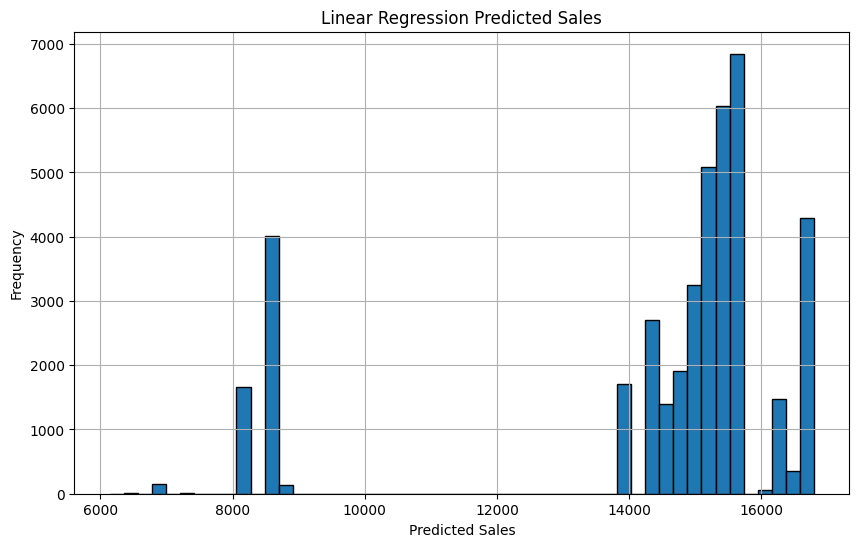

In [176]:
test_predictions = pipeline.predict(X_test)
predicted_sales_df = pd.DataFrame({'Predicted_Sales': test_predictions})

print("\nDescriptive Statistics of Predicted Sales:")
print(predicted_sales_df['Predicted_Sales'].describe())


import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(predicted_sales_df['Predicted_Sales'], bins=50, edgecolor='black')
plt.title('Linear Regression Predicted Sales')
plt.xlabel('Predicted Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

XGBREGRESSOR MODEL

In [ ]:
import xgboost as xgb

xgb_sales = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_sales.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [183]:
xgb_sales_predictions = xgb_sales.predict(X_test)


Descriptive Statistics of Predicted Sales:
count    41088.000000
mean      5575.572754
std       2479.182129
min       -478.228302
25%       5581.162109
50%       6150.333496
75%       6886.275879
max      11304.309570
Name: Predicted_Sales, dtype: float64


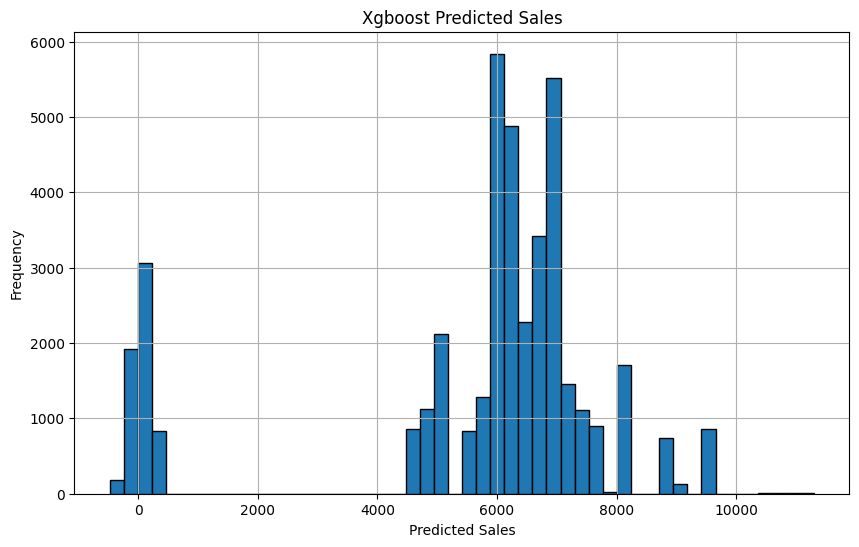

In [184]:

xgb_predicted_sales_df = pd.DataFrame({'Predicted_Sales': xgb_sales_predictions})

print("\nDescriptive Statistics of Predicted Sales:")
print(xgb_predicted_sales_df['Predicted_Sales'].describe())


import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(xgb_predicted_sales_df['Predicted_Sales'], bins=50, edgecolor='black')
plt.title('Xgboost Predicted Sales')
plt.xlabel('Predicted Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Random forest model

In [185]:
from sklearn.ensemble import RandomForestRegressor

rf_sales = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_sales.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [186]:
rf_sales_predictions = rf_sales.predict(X_test)


Descriptive Statistics of Predicted Sales:
count    41088.000000
mean      5772.663798
std       2493.029090
min          0.000000
25%       5335.449177
50%       6644.646631
75%       7251.407480
max       9119.400172
Name: Predicted_Sales, dtype: float64


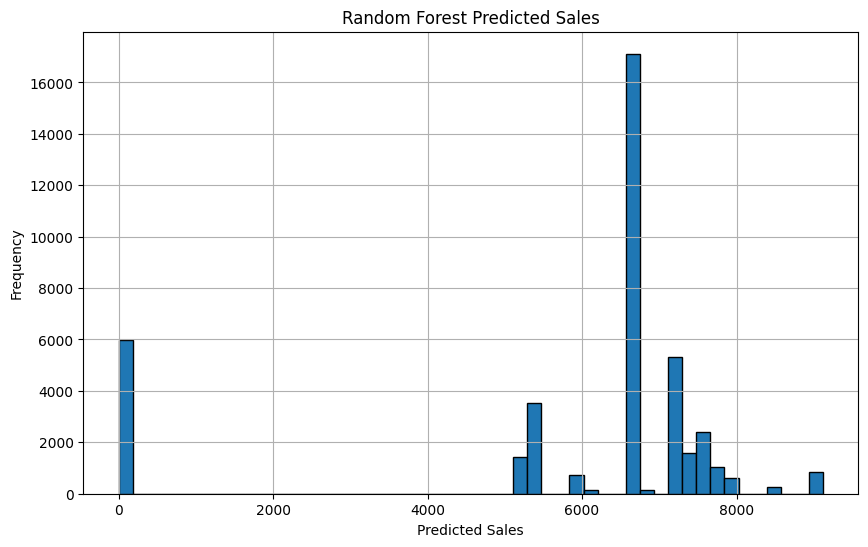

In [187]:

rf_predicted_sales_df = pd.DataFrame({'Predicted_Sales': rf_sales_predictions})

print("\nDescriptive Statistics of Predicted Sales:")
print(rf_predicted_sales_df['Predicted_Sales'].describe())


import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(rf_predicted_sales_df['Predicted_Sales'], bins=50, edgecolor='black')
plt.title('Random Forest Predicted Sales')
plt.xlabel('Predicted Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Model selection. There is no sales record to validate predictions so i will export random forest predictions  that do not have negative sales value to csv

Random forest regression export

In [191]:
random_forest_sales_forecast_prediction = pd.DataFrame(
{
    'Id': test_df['Id'],
    'Sales': rf_predicted_sales_df['Predicted_Sales']
})
random_forest_sales_forecast_prediction.tail(50)

,Id,Sales
41038,41039,6126.183712
41039,41040,6012.208897
41040,41041,6012.208897
41041,41042,6012.208897
41042,41043,6012.208897
41043,41044,6012.208897
41044,41045,6012.208897
41045,41046,6012.208897
41046,41047,6012.208897
41047,41048,6012.208897


In [188]:
random_forest_sales_forecast_prediction = pd.DataFrame(
{
    'Id': test_df['Id'],
    'Sales': rf_predicted_sales_df['Predicted_Sales']
})

from google.colab import files
random_forest_sales_forecast_prediction.to_csv('random_forest_sales_forecast_prediction.csv', index=False)
files.download('random_forest_sales_forecast_prediction.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>